# 01a — Arquitectura Transformer

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01a-transformer.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> seguir el orden propuesto: Transformer → LLMs → Embeddings → Vector
> DB.

In [1]:
!pip install -q matplotlib

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## Arquitectura Transformer

### El problema que resuelve

Antes de la aparición del modelo Transformer, los modelos secuenciales
dominaban el procesamiento de lenguaje (RNN, LSTM, GRU, etc.). Estos
modelos se catalogan bajo el paraguas de **modelos secuenciales** por su
forma de procesar los tokens, uno tras otro, de forma secuencial, lo que
imponía ciertas restricciones: - Impide la paralelización (cada token
depende del anterior). - Sufre desvanecimiento de gradiente en
secuencias largas. - Dificulta capturar dependencias de largo alcance.

La arquitectura **Transformer** (Vaswani et al., 2017) resolvió estos
problemas introduciendo el **mecanismo de atención** para reemplazar el
**mecanisno de recurrencia** (limitada) usado hasta el momento, algo que
permitió procesar un conjunto de tokens en paralelo y modelar
dependencias directas entre cualquier par de posiciones de ese conjunto
de tokens.

<figure>
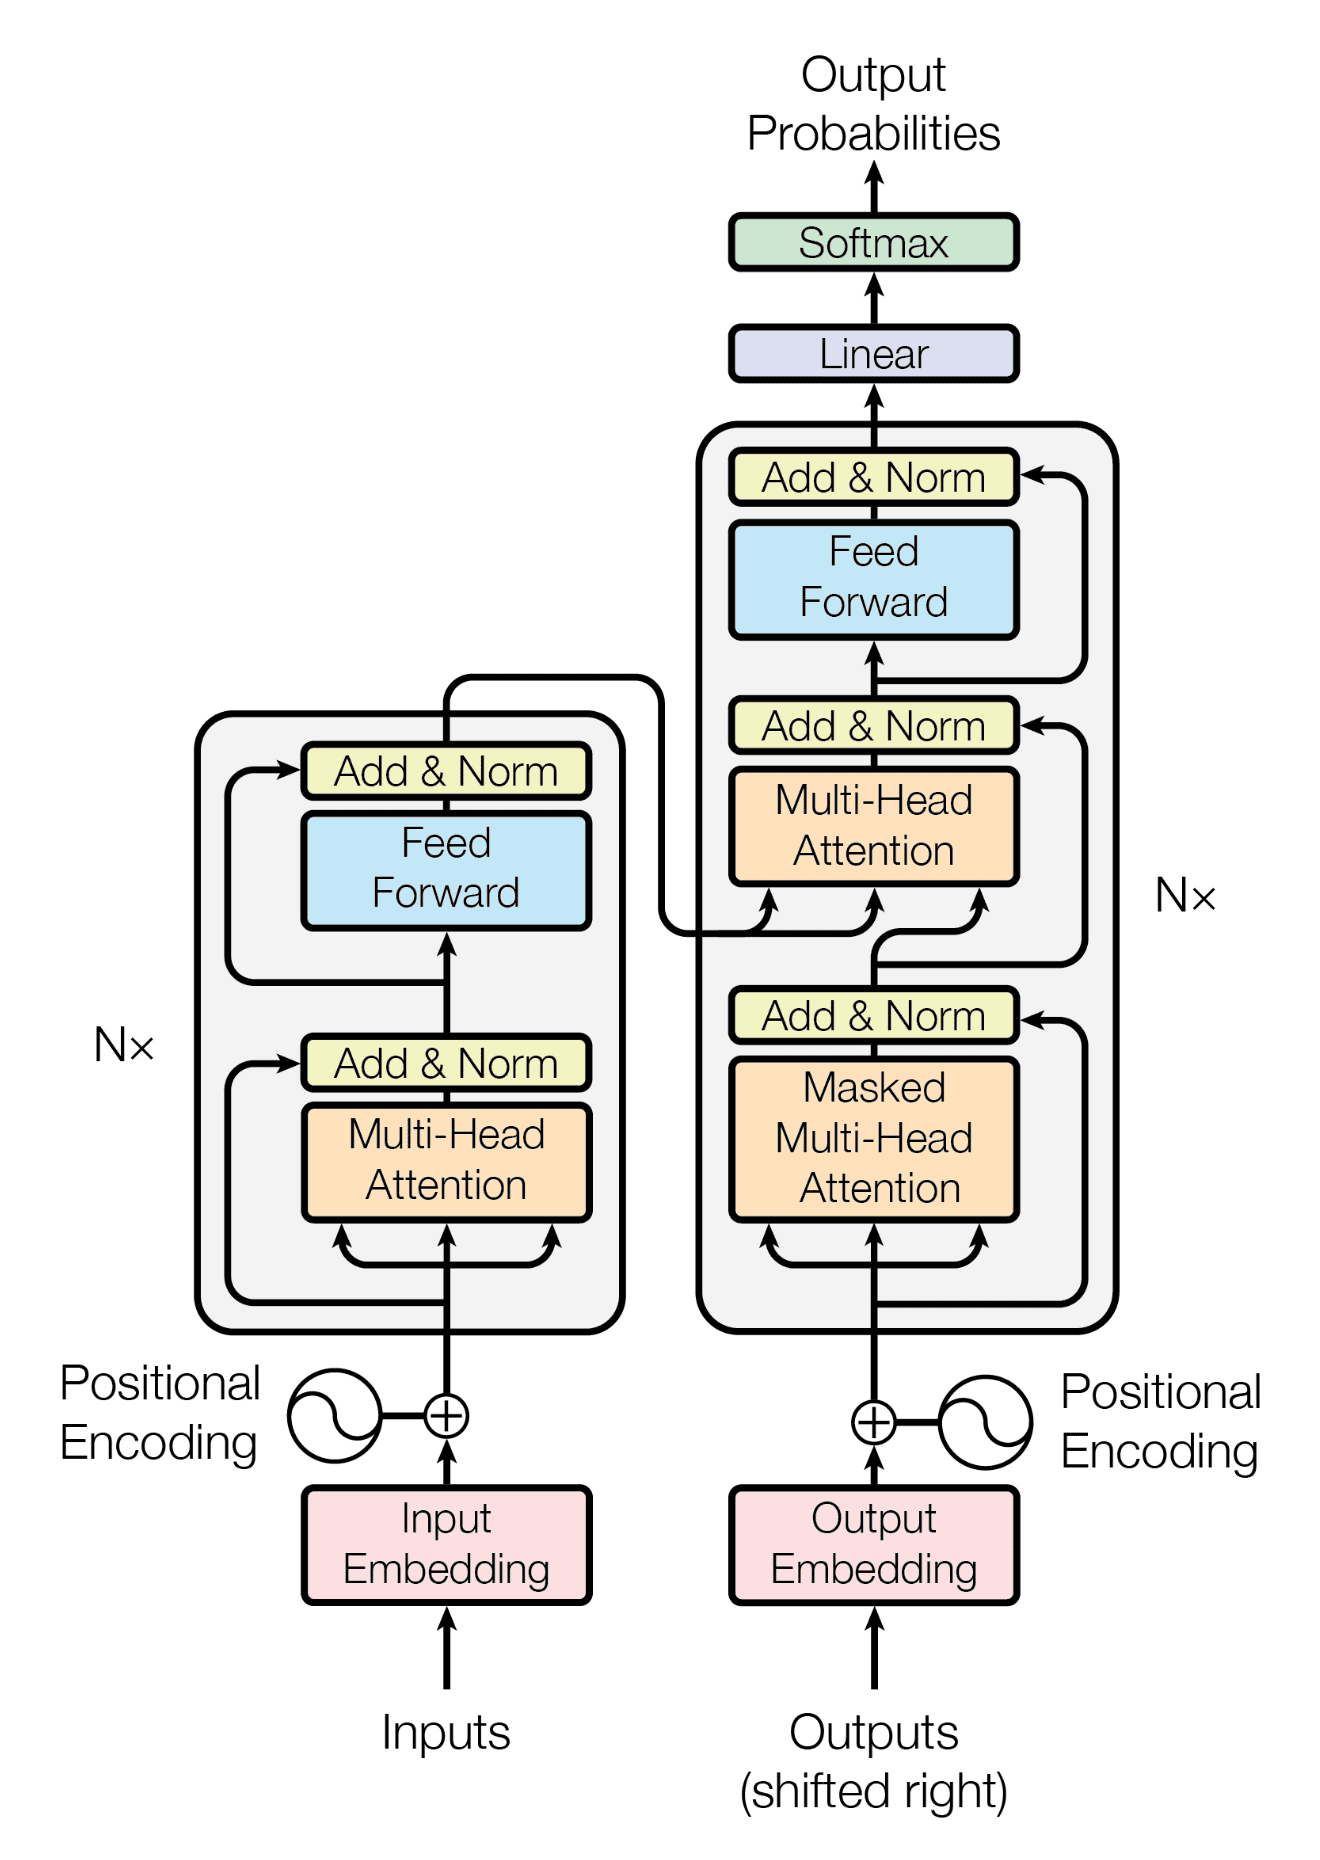
<figcaption aria-hidden="true">Arquitectura Transformer —
encoder-decoder con atención multi-cabeza (Vaswani et al., 2017, Figure
1)</figcaption>
</figure>

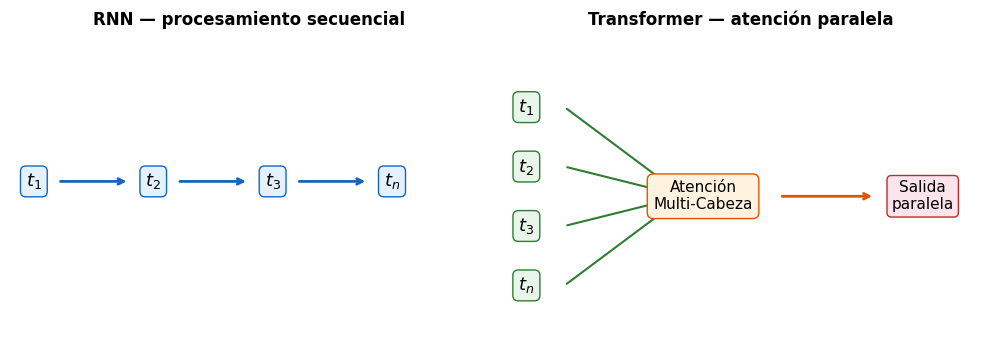

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.patch.set_facecolor('white')

rnn_nodes = ['$t_1$', '$t_2$', '$t_3$', '$t_n$']

# RNN — procesamiento secuencial
ax1.set_title("RNN — procesamiento secuencial", fontsize=12, fontweight='bold')
ax1.axis('off')
x_positions = [0.05, 0.3, 0.55, 0.8]
for i, (label, x) in enumerate(zip(rnn_nodes, x_positions)):
    ax1.text(x, 0.5, label, fontsize=13, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#e3f2fd', edgecolor='#1565c0'))
    if i < len(rnn_nodes) - 1:
        ax1.annotate('', xy=(x_positions[i+1] - 0.05, 0.5),
                     xytext=(x + 0.05, 0.5),
                     arrowprops=dict(arrowstyle='->', color='#1565c0', lw=2))

# Transformer — atención paralela
ax2.set_title("Transformer — atención paralela", fontsize=12, fontweight='bold')
ax2.axis('off')
y_positions = [0.75, 0.55, 0.35, 0.15]
for label, y in zip(rnn_nodes, y_positions):
    ax2.text(0.05, y, label, fontsize=13, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', edgecolor='#2e7d32'))
    ax2.annotate('', xy=(0.38, 0.45), xytext=(0.13, y),
                 arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.5))

ax2.text(0.42, 0.45, 'Atención\nMulti-Cabeza', fontsize=11, ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3e0', edgecolor='#e65100'))
ax2.annotate('', xy=(0.78, 0.45), xytext=(0.58, 0.45),
             arrowprops=dict(arrowstyle='->', color='#e65100', lw=2))
ax2.text(0.88, 0.45, 'Salida\nparalela', fontsize=11, ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fce4ec', edgecolor='#c62828'))

plt.tight_layout()
plt.show()

### Atención multi-cabeza (Multi-Head Attention)

El núcleo del Transformer se encuentra en el mecanismo de **scaled
dot-product attention** (atención basada en el producto escalar). En
este proceso, para cada token se calculan tres vectores numéricos, que
*presuponen* el siguiente contenido semántico:

- **Q (Query):** qué información busca este token.
- **K (Key):** qué información ofrece cada token.
- **V (Value):** el contenido real de cada token.

A partir de estos, la atención se calcula como:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

donde el producto $Q·K^T$ mide la similitud entre cada par de tokens; el
factor $\sqrt{d_k}$ sirve como escala normalizadora para evitar que los
valores crezcan demasiado en módulo; la **multi-cabeza** ejecuta este
proceso en paralelo con pesos distintos, permitiendo al modelo *atender*
a diferentes relaciones simultáneamente (sintaxis, semántica,
coreferencias, etc.).

<figure>
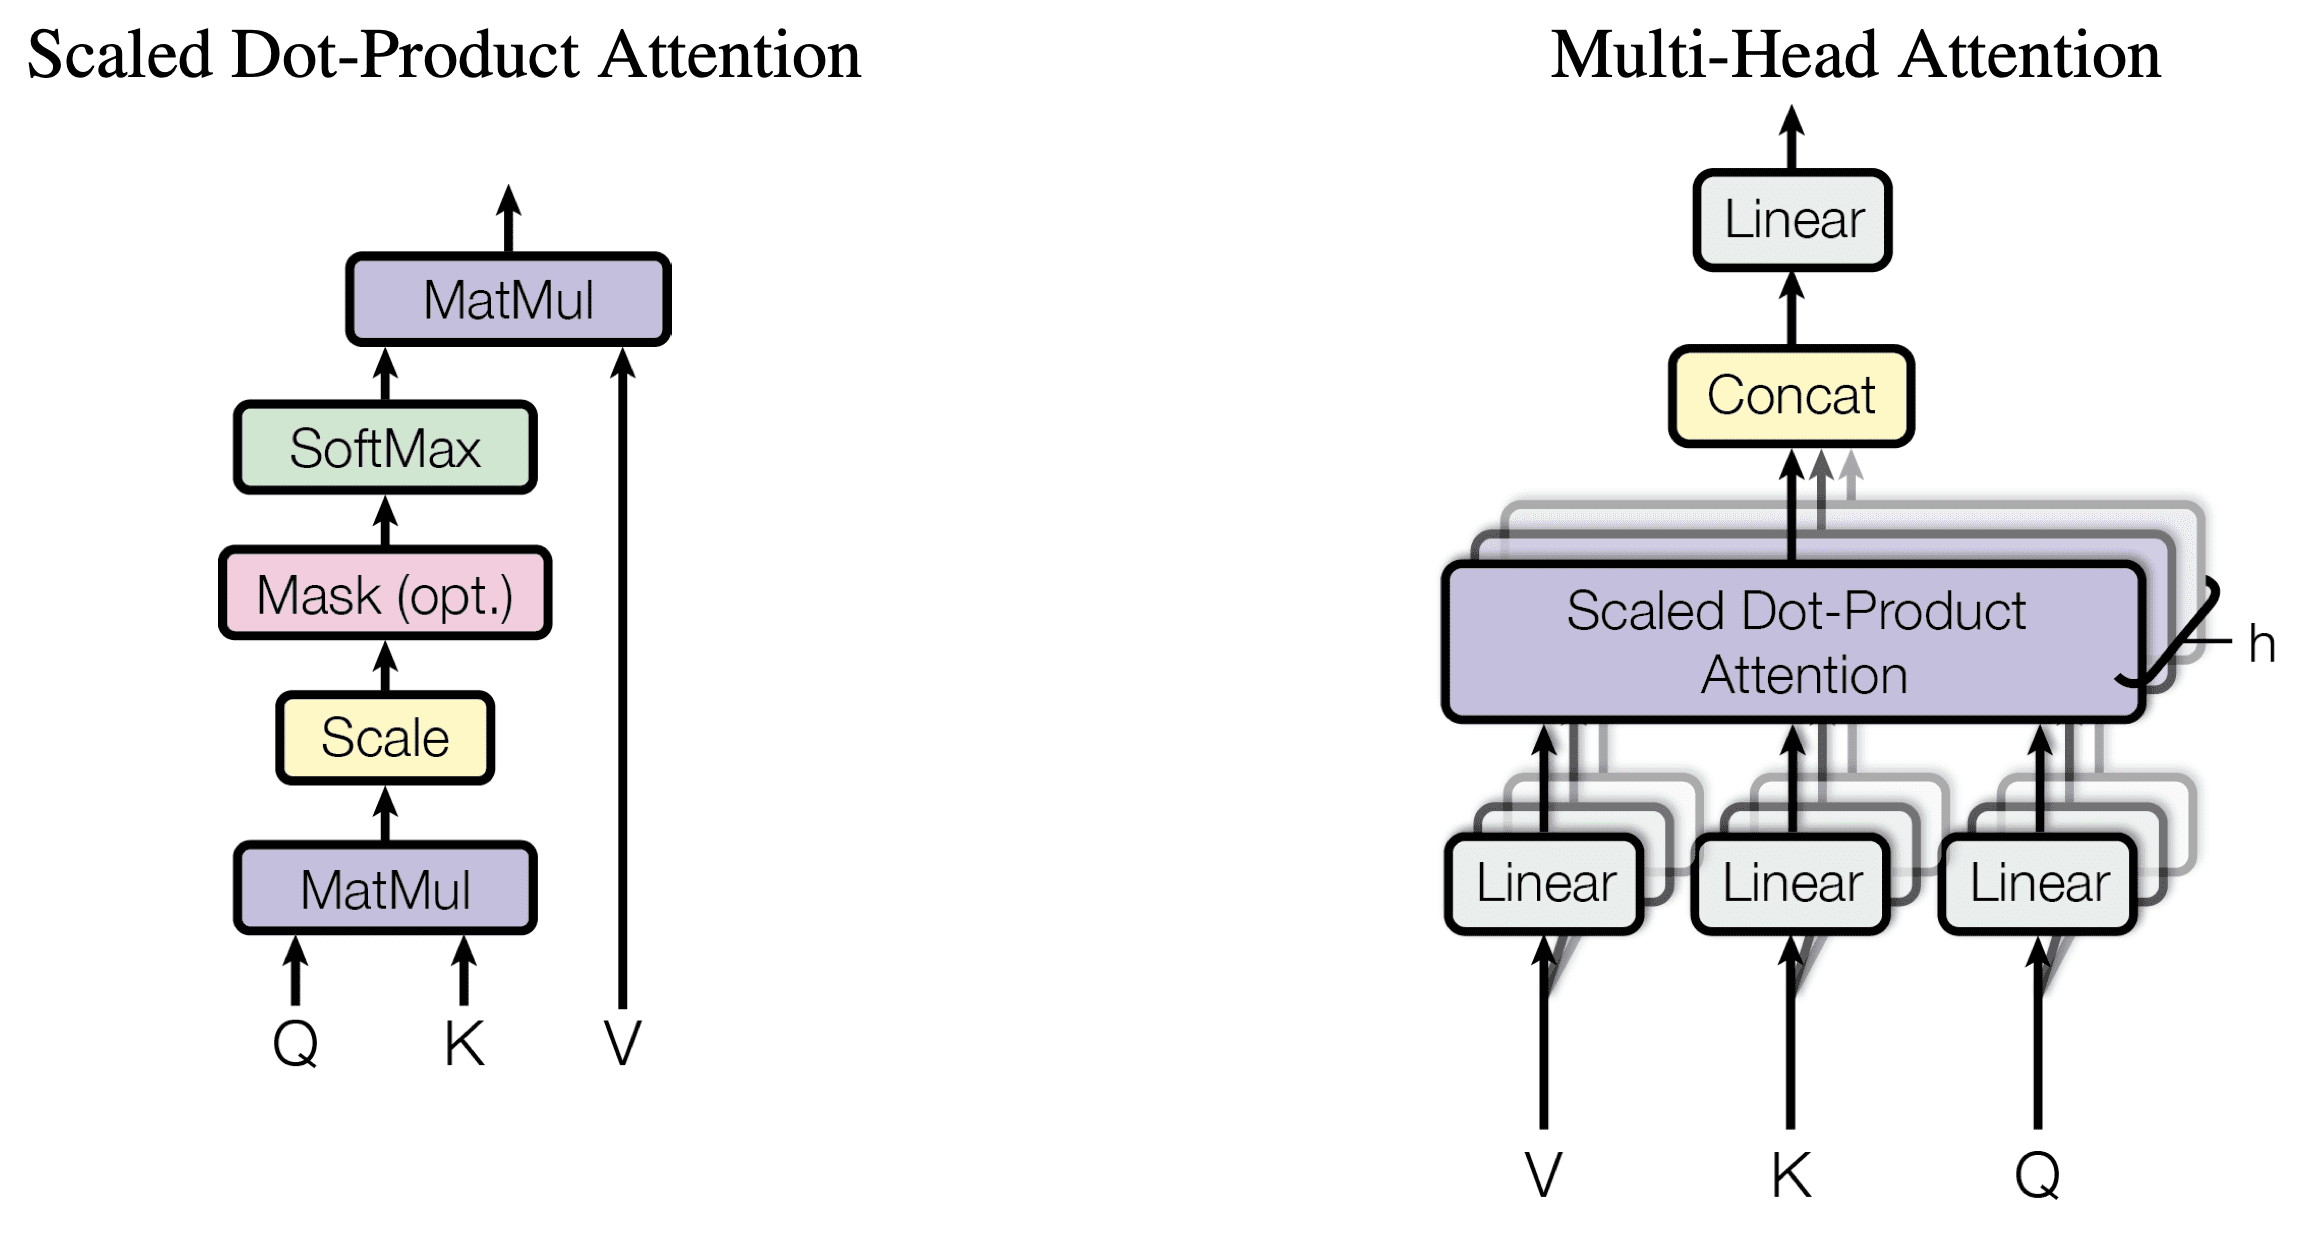
<figcaption aria-hidden="true">Scaled Dot-Product Attention (izquierda)
y Atención multi-cabeza (derecha) (Vaswani et al., 2017, Figure
2)</figcaption>
</figure>

#### Scaled Dot-Product Attention — Low Level (numpy)

In [4]:
def scaled_dot_product_attention_numpy(Q, K, V):
    """Atención paso a paso con numpy. Muestra la matemática subyacente."""
    d_k = K.shape[-1]
    scores = np.matmul(Q, K.transpose(0, 2, 1))
    scores = scores / np.sqrt(d_k)
    weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    output = np.matmul(weights, V)
    return output, weights

np.random.seed(42)
batch, seq_len, d_k = 1, 3, 4
Q = np.random.randn(batch, seq_len, d_k)
K = np.random.randn(batch, seq_len, d_k)
V = np.random.randn(batch, seq_len, d_k)

out_np, attn_np = scaled_dot_product_attention_numpy(Q, K, V)
print("Matriz de atención (numpy):")
print(np.round(attn_np[0], 3))
print("\nCada fila suma 1:", np.round(attn_np[0].sum(axis=1), 3))


Matriz de atención (numpy):
[[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

Cada fila suma 1: [1. 1. 1.]

#### Scaled Dot-Product Attention — High Level (PyTorch)

In [5]:
def scaled_dot_product_attention_torch(Q, K, V):
    """Atención paso a paso con PyTorch, equivalente a la versión numpy."""
    d_k = K.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

Qt = torch.from_numpy(Q)
Kt = torch.from_numpy(K)
Vt = torch.from_numpy(V)

out_th, attn_th = scaled_dot_product_attention_torch(Qt, Kt, Vt)
print("Matriz de atención (PyTorch):")
print(np.round(attn_th.numpy()[0], 3))

print(f"\n¿Resultados idénticos? {np.allclose(out_np, out_th.numpy(), atol=1e-6)}")


Matriz de atención (PyTorch):
[[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

¿Resultados idénticos? True

#### Multi-Head Attention — Low Level (numpy)

In [6]:
def multi_head_attention_numpy(Q, K, V, num_heads=2):
    """Multi-head atención desde cero: divide en cabezas, atiende, concatena, proyecta."""
    batch, seq_len, d_model = Q.shape
    d_k = d_model // num_heads

    Q_heads = Q.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    K_heads = K.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    V_heads = V.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)

    outputs, attn_weights = [], []
    for h in range(num_heads):
        scores = Q_heads[:, h] @ K_heads[:, h].swapaxes(-2, -1) / np.sqrt(d_k)
        weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
        outputs.append(weights @ V_heads[:, h])
        attn_weights.append(weights)

    concat = np.concatenate(outputs, axis=-1)
    return concat, attn_weights

Q_mh = np.random.randn(1, 3, 8)
K_mh = np.random.randn(1, 3, 8)
V_mh = np.random.randn(1, 3, 8)
out_mh, attn_mh = multi_head_attention_numpy(Q_mh, K_mh, V_mh, num_heads=2)
print(f"Salida multi-head: {out_mh.shape}")
print(f"Cabeza 0 pesos:\n{np.round(attn_mh[0][0], 3)}")
print(f"Cabeza 1 pesos:\n{np.round(attn_mh[1][0], 3)}")
print(f"\nCada cabeza atiende de forma distinta (diferentes pesos).")


Salida multi-head: (1, 3, 8)
Cabeza 0 pesos:
[[0.427 0.361 0.211]
 [0.307 0.588 0.105]
 [0.143 0.711 0.146]]
Cabeza 1 pesos:
[[0.384 0.34  0.277]
 [0.201 0.099 0.7  ]
 [0.34  0.282 0.377]]

Cada cabeza atiende de forma distinta (diferentes pesos).

#### Multi-Head Attention — High Level (PyTorch)

In [7]:
embed_dim = 8
num_heads = 2
mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

Qt_mh = torch.from_numpy(Q_mh).float()
Kt_mh = torch.from_numpy(K_mh).float()
Vt_mh = torch.from_numpy(V_mh).float()

out_th_mh, attn_th_mh = mha(Qt_mh, Kt_mh, Vt_mh, need_weights=True)
print(f"Salida nn.MultiheadAttention: {out_th_mh.shape}")
print(f"Pesos de atención:\n{np.round(attn_th_mh.detach().numpy(), 3)}")
print(f"\nParámetros entrenables de la capa: {sum(p.numel() for p in mha.parameters())}")


Salida nn.MultiheadAttention: torch.Size([1, 3, 8])
Pesos de atención:
[[[0.355 0.274 0.37 ]
  [0.278 0.213 0.509]
  [0.216 0.438 0.345]]]

Parámetros entrenables de la capa: 288

#### Visualización de atención

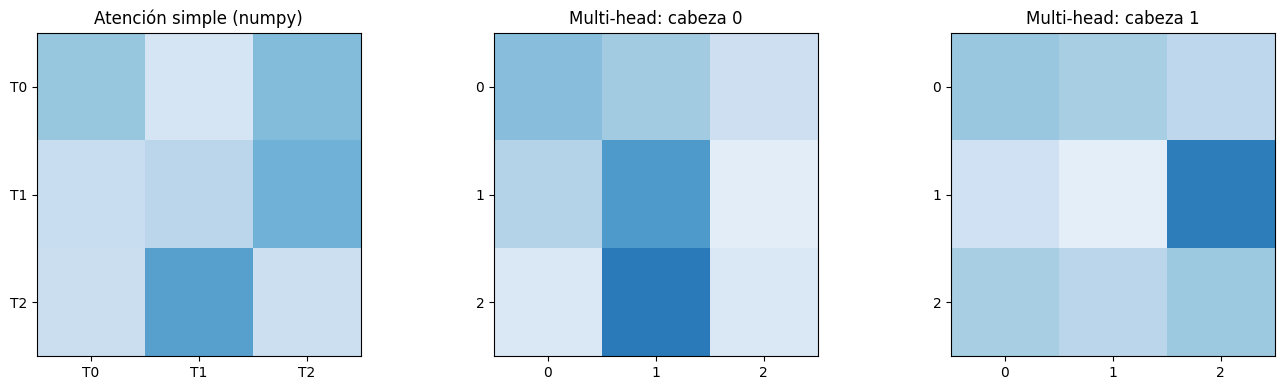

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(attn_np[0], cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Atención simple (numpy)")
axes[0].set_xticks(range(seq_len)); axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels([f"T{i}" for i in range(seq_len)])
axes[0].set_yticklabels([f"T{i}" for i in range(seq_len)])

axes[1].imshow(attn_mh[0][0], cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Multi-head: cabeza 0")
axes[1].set_xticks(range(seq_len)); axes[1].set_yticks(range(seq_len))

axes[2].imshow(attn_mh[1][0], cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Multi-head: cabeza 1")
axes[2].set_xticks(range(seq_len)); axes[2].set_yticks(range(seq_len))

plt.tight_layout()
plt.show()
plt.close(fig)


### Codificación posicional

La atención es **permutation-invariant**: si cambiamos el orden de los
tokens, el resultado es el mismo. Para inyectar información de posición,
el Transformer añade un vector de **codificación posicional** a cada
embedding de token.

La codificación posicional sinusoidal usa frecuencias diferentes para
cada dimensión:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

#### Codificación posicional — Low Level (numpy)

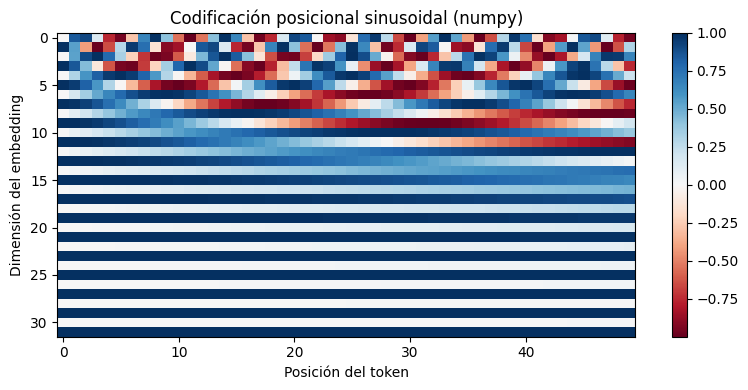

In [9]:
def positional_encoding_numpy(seq_len, d_model):
    """Codificación posicional sinusoidal desde cero."""
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(pos * angle_rates[:, 0::2])
    pe[:, 1::2] = np.cos(pos * angle_rates[:, 1::2])
    return pe

pe_np = positional_encoding_numpy(50, 32)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pe_np.T, cmap="RdBu", aspect="auto")
ax.set_xlabel("Posición del token")
ax.set_ylabel("Dimensión del embedding")
ax.set_title("Codificación posicional sinusoidal (numpy)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close(fig)


#### Codificación posicional — High Level (PyTorch)

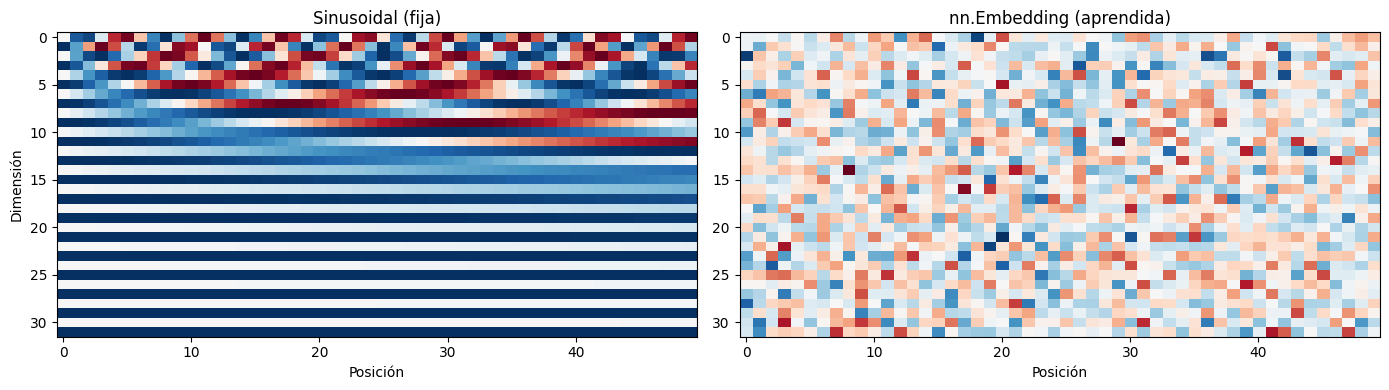

La versión aprendida se adapta a los datos; la sinusoidal es fija pero extrapola a secuencias más largas.

In [10]:
vocab_size = 50
d_model = 32
pos_embedding = nn.Embedding(vocab_size, d_model)

posiciones = torch.arange(vocab_size)
pe_aprendida = pos_embedding(posiciones).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(pe_np.T, cmap="RdBu", aspect="auto")
axes[0].set_title("Sinusoidal (fija)")
axes[0].set_xlabel("Posición"); axes[0].set_ylabel("Dimensión")

axes[1].imshow(pe_aprendida.T, cmap="RdBu", aspect="auto")
axes[1].set_title("nn.Embedding (aprendida)")
axes[1].set_xlabel("Posición")

plt.tight_layout()
plt.show()
plt.close(fig)
print("La versión aprendida se adapta a los datos; la sinusoidal es fija pero extrapola a secuencias más largas.")


### Variantes de la arquitectura

| Variante | Arquitectura | Ejemplos | Uso principal |
|------------------|------------------|------------------|------------------|
| **Encoder-only** | Solo encoder (atención bidireccional) | BERT, RoBERTa | Clasificación, NER, embeddings |
| **Decoder-only** | Solo decoder (atención causal/masked) | GPT, Llama, Qwen, Gemma, DeepSeek | Generación de texto, chat |
| **Encoder-decoder** | Encoder + decoder con cross-attention | T5, BART | Traducción, resumen, QA |

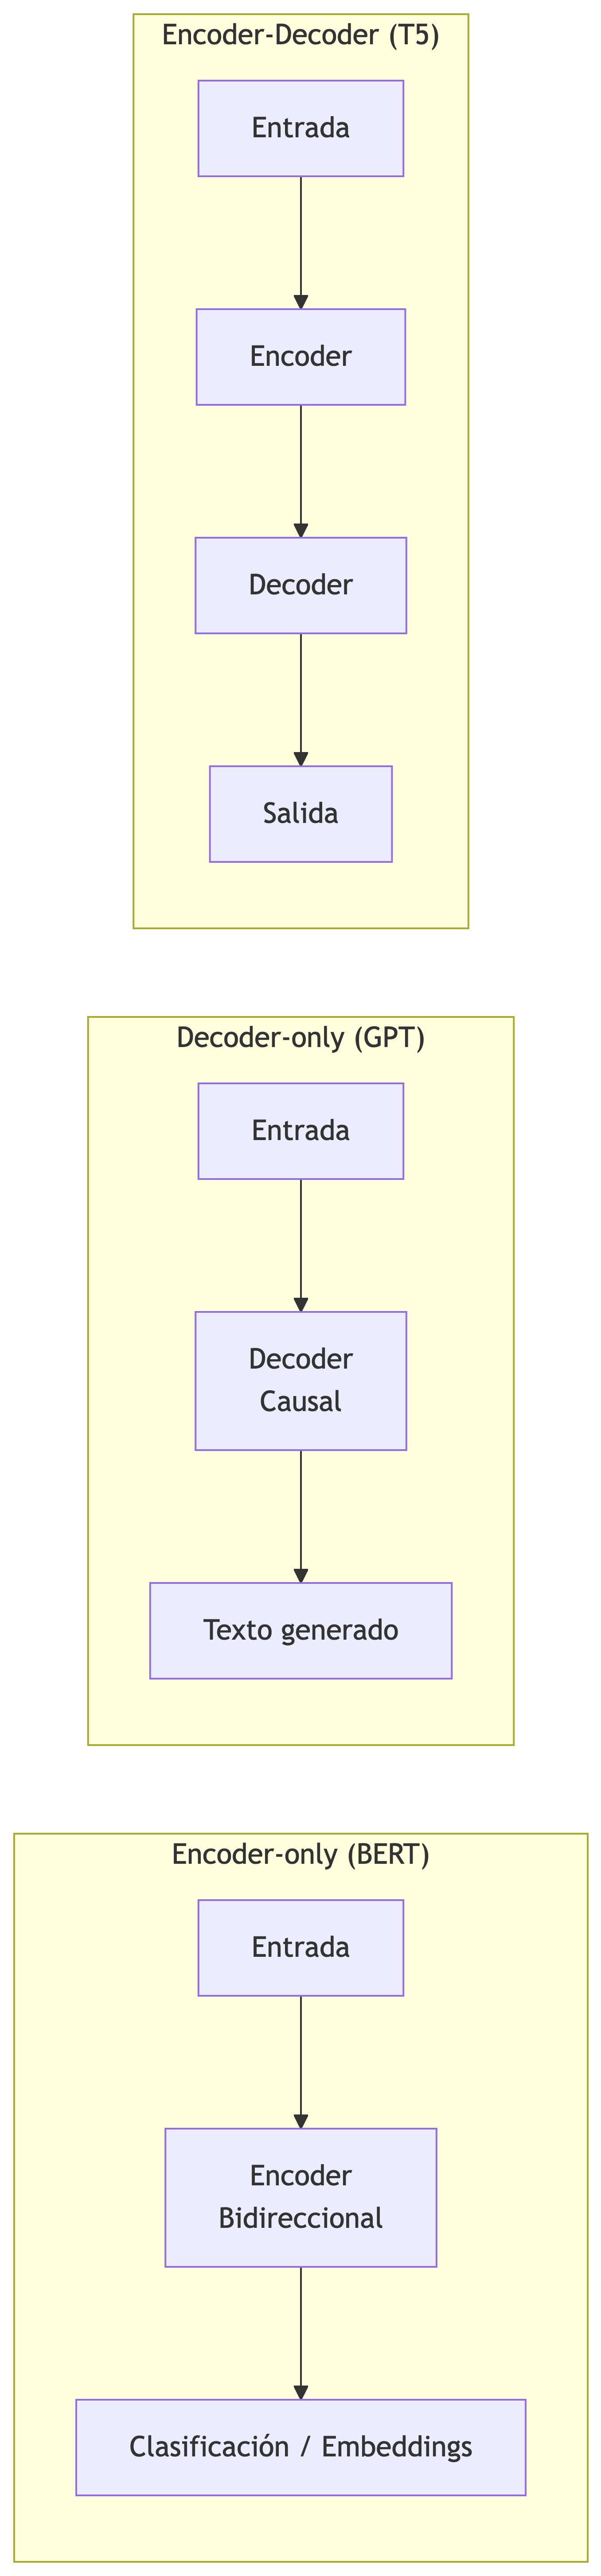

> **Lectura obligatoria**
>
> Vaswani, A. et al. (2017). **Attention is All You Need**. NeurIPS.
>
> Leer secciones 3-5: Scaled Dot-Product Attention, Multi-Head
> Attention, Positional Encoding y el resumen de la arquitectura
> completa.
>
> [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)

------------------------------------------------------------------------

> Continúa con **[01b-llms.qmd](01b-llms.qmd)** — Grandes Modelos de
> Lenguaje e inferencia.